In [1]:
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import netket as nk
import netket.experimental as nkx
import sys
sys.path.append('..')
from NES_VMC import NESTotalAnsatz, create_machine,init_sampler_state,\
    generate_random_initial_states,ha,SingleStateAnsatz,create_single_machine,\
        create_machine_matrix,Ham_psi,Ham_Psi,NES_loss_energy,nes_vmc_gradient,hi,E_fcis,mcmc_sampler_multichain,\
        NESFermionHopRule,compute_qgt,sampler_info
import optax
from typing import Callable
from functools import partial
from jax.flatten_util import ravel_pytree
import time

# ========== 你原有全局参数（直接复用） ==========
# 单系统希尔伯特空间
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,
    s=1/2,
    n_fermions_per_spin=(1,1),
)
K = 2  # NES 扩展副本数
hi_ext = hi ** K  # 扩展希尔伯特空间
SINGLE_SIZE = hi.size  # 单个子系统维度 = 4
single_edges = ((0, 1), (2, 3))  # 费米子跃迁边
g = nk.graph.Graph(edges=single_edges)
single_rule = nk.sampler.rules.FermionHopRule(hi, graph=g)
tensor_rule = nk.sampler.rules.TensorRule(hi_ext, [single_rule] * K)

total_ansatz = NESTotalAnsatz(4,K,12,rngs=nnx.Rngs(11))
total_machine, total_graphdef,total_params = create_machine(total_ansatz)
total_matrix_machine, total_graphdef,total_params = create_machine_matrix(total_ansatz)

single_machine_list = []
for ansatz in total_ansatz.single_ansatz_list:
    m, g, p = create_single_machine(ansatz)
    single_machine_list.append(m)

/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: You can load logged data with nk.utils.history.HistoryDict.from_file(data.log).

H₂ FCI 基准能量
E0 = -1.01546825 Ha  |  激发能：0.0000 eV
E1 = -0.87542794 Ha  |  激发能：3.8107 eV
E2 = -0.42938376 Ha  |  激发能：15.9482 eV
E3 = -0.26922131 Ha  |  激发能：20.3064 eV


In [9]:
import jax
import jax.numpy as jnp
import netket as nk

SINGLE_SIZE = hi.size

@nk.utils.struct.dataclass
class NESFermionHopRule(nk.sampler.rules.MetropolisRule):
    edges: jnp.ndarray
    K: int = nk.utils.struct.static_field()
    single_size: int = nk.utils.struct.static_field()

    def _check_duplicate(self, sigma_ext):
        """NES约束：子组态不重复
        🔥 核心修复：返回【标量布尔值】，匹配while_loop初始值形状
        """
        sub = sigma_ext.reshape((-1, self.K, self.single_size))
        # 原代码返回数组 → 改为 .squeeze() 压缩成标量！
        return jnp.any(jnp.all(sub[...,1:,:] == sub[...,0:1,:], axis=-1), axis=-1).squeeze()

    def transition(self, sampler, machine, parameters, state, rng, sigma):
        """跃迁规则（完全不变）"""
        batch_size = sigma.shape[0]
        key1, key2 = jax.random.split(rng)

        e_idx = jax.random.randint(key1, (batch_size,), 0, self.edges.shape[0])
        sel_e = self.edges[e_idx]
        i, j = sel_e[:,0], sel_e[:,1]

        sigma_cand = sigma.at[jnp.arange(batch_size),i].set(sigma[jnp.arange(batch_size),j])
        sigma_cand = sigma_cand.at[jnp.arange(batch_size),j].set(sigma[jnp.arange(batch_size),i])

        invalid = self._check_duplicate(sigma_cand)
        new_sigma = jnp.where(invalid[:, None], sigma, sigma_cand)

        return new_sigma, None

    def random_state(self, sampler, machine, parameters, state, rng):
        """随机态生成（仅修复标量形状）"""
        sigma_shape = state.σ.shape
        hilbert = sampler.hilbert

        def gen_single(key):
            max_tries = 100
            def cond(c): 
                return (c[0] < max_tries) & c[2]
            
            def body(c):
                tries, k, _, _ = c
                k, k_new = jax.random.split(k)
                s = hilbert.random_state(k_new)
                is_dup = self._check_duplicate(s)  # 现在是标量！
                return (tries + 1, k, is_dup, s)
            
            # 初始值 c[2] = True（标量布尔值），和body返回值形状完全匹配
            init_c = (0, key, True, hilbert.random_state(key))
            final_c = jax.lax.while_loop(cond, body, init_c)
            tries, _, is_dup, s = final_c
            return jax.lax.cond(is_dup, lambda: hilbert.random_state(key), lambda: s)
        
        keys = jax.random.split(rng, sigma_shape[0])
        return jax.vmap(gen_single)(keys)

In [ ]:
N_CHAINS = 16
N_WARMUP = 100
N_SAMPLES_PER_CHAIN = 200
SWEEP_SIZE = 30
N_ITER =50
SINGLE_SIZE = hi.size  # 单个子系统维度 = 4

ext_edges = []
for k in range(K):
    offset = k * SINGLE_SIZE
    for (i, j) in single_edges:
        ext_edges.append((i + offset, j + offset))
ext_edges = jnp.array(ext_edges)  # 转为jax数组（关键修复）
print(ext_edges)

nes_rule = NESFermionHopRule(edges=ext_edges, K=K, single_size=SINGLE_SIZE)
nes_sampler = nk.sampler.MetropolisSampler(
    hilbert=hi_ext,
    rule=nes_rule,
    n_chains=N_CHAINS,
    sweep_size=SWEEP_SIZE,
)

sampler_state = nes_sampler.init_state(total_machine, total_params, seed=1)
samples_raw, sampler_state = nes_sampler.sample(
    total_machine, total_params, state=sampler_state, chain_length=40
)
samples_raw.shape

[[0 1]
 [2 3]
 [4 5]
 [6 7]]


(16, 40, 8)

In [12]:
samples = samples_raw.reshape(-1, hi_ext.size)
x_batch = samples.reshape(-1, K, 4)
# 3. 计算能量和自然梯度（逻辑和原代码一致）
grad, loss_mean, E_L_mean = nes_vmc_gradient(ha=ha,
                                                total_matrix_machine=total_matrix_machine,
                                                total_machine=total_machine,
                                                single_machine_list=single_machine_list,
                                                total_params=total_params,
                                            x_batch=samples.reshape(-1,K,4))

In [37]:
N_CHAINS = 16
N_WARMUP = 100
N_SAMPLES_PER_CHAIN = 200
SWEEP_SIZE = 30
N_ITER =400
SINGLE_SIZE = hi.size  # 单个子系统维度 = 4


total_ansatz = NESTotalAnsatz(4,K,12,rngs=nnx.Rngs(11))
total_machine, total_graphdef,total_params = create_machine(total_ansatz)
total_matrix_machine, total_graphdef,total_params = create_machine_matrix(total_ansatz)

single_machine_list = []
for ansatz in total_ansatz.single_ansatz_list:
    m, g, p = create_single_machine(ansatz)
    single_machine_list.append(m)
    
    

optimizer = optax.sgd(learning_rate=0.01)
opt_state = optimizer.init(total_params)

ext_edges = []
for k in range(K):
    offset = k * SINGLE_SIZE
    for (i, j) in single_edges:
        ext_edges.append((i + offset, j + offset))
ext_edges = jnp.array(ext_edges)  # 转为jax数组（关键修复）

nes_rule = NESFermionHopRule(edges=ext_edges, K=K, single_size=SINGLE_SIZE)
nes_sampler = nk.sampler.MetropolisSampler(
    hilbert=hi_ext,
    rule=nes_rule,
    n_chains=16,
    sweep_size=20
)


# 采样器状态初始化（替代原 init_sampler_state）
sampler_rng = jax.random.PRNGKey(21)
sampler_state = nes_sampler.init_state(total_machine, total_params, sampler_rng)

# ==================== 训练循环（仅替换采样部分） ====================
print("\n" + "="*60)
print("开始多链 NES-VMC 训练 (NetKet 自定义采样器 + 朴素梯度下降)")
print("="*60)
print(f"基态能量={E_fcis[0]:.8f} Ha| 第一激发态能量={E_fcis[1]:.8f} Ha| 第二激发态能量={E_fcis[2]:.8f} Ha")

history = {
    'step': [],
    'energy_0st': [],
    'energy_1st': [],
    'energy_std': [],
    'loss': [],
    'params': [],
    'E_Lmatrix':[],
    'natural_grad':[],
    'grad_flat':[],
    'samples':[],
    'log_Psi':[],
    'log_M':[],
    'log_Psi_mean':[],
    'log_Psi_min':[],
    'log_Psi_max':[],
    'grad_norm':[],
}

start_time = time.time()
for step in range(N_ITER):
    # 2. 正式采样
    samples_raw, sampler_state = nes_sampler.sample(
        machine=total_machine, parameters=total_params, 
        state=sampler_state, chain_length=N_SAMPLES_PER_CHAIN
    )
        # 3. 维度重塑，适配梯度函数输入
    samples = samples_raw.reshape(-1, hi_ext.size)
    x_batch = samples.reshape(-1, K, 4)
    # 3. 计算能量和自然梯度（逻辑和原代码一致）
    grad, loss_mean, E_L_mean = nes_vmc_gradient(ha=ha,
                                                 total_matrix_machine=total_matrix_machine,
                                                 total_machine=total_machine,
                                                 single_machine_list=single_machine_list,
                                                 total_params=total_params,
                                                 x_batch=samples.reshape(-1,K,4))
    #grad = jax.tree_util.tree_map(lambda x: x * 2, grad)
    
    # grad_flat , grad_unravel_fn = ravel_pytree(grad)
    # qgt_reg, unravel_fn = compute_qgt(total_machine, total_params, samples.reshape(-1,2,4), diag_shift=0.1)
    
    # # # 自然梯度求解
    # natural_grad_flat = jnp.linalg.solve(qgt_reg, grad_flat)
    # natural_grad = grad_unravel_fn(natural_grad_flat)
    # grad = natural_grad
        
    # 4. 更新参数
    updates, opt_state = optimizer.update(grad, opt_state, total_params)
    total_params = optax.apply_updates(total_params, updates)
    
    
    
    log_Psi_batch = total_machine(total_params, samples.reshape(-1,K,4))
    eig_vals, eig_vecs = jnp.linalg.eigh(E_L_mean)
    grad_norm = jnp.linalg.norm(grad_flat)
    
    
    history['step'].append(step)
    history['E_Lmatrix'].append(E_L_mean)
    history['samples'].append(samples)
    history['loss'].append(loss_mean)
    history['log_Psi_mean'].append(log_Psi_batch.mean())
    history['log_Psi_min'].append(log_Psi_batch.min())
    history['log_Psi_max'].append(log_Psi_batch.max())
    history['grad_norm'].append(grad_norm)
    history['energy_0st'].append(eig_vals[0])
    history['energy_1st'].append(eig_vals[1])
    history['params'].append(total_params)
    # 5. 记录历史
    if step % 50 == 0 or step == N_ITER - 1:
        # --------------------- 【NES-VMC 监控模板】直接用 ---------------------
        # 1. 监控 log_Psi
        #log_Psi_batch = total_machine(total_params, samples.reshape(-1,K,4))
        print(f"log_Psi: mean={log_Psi_batch.mean():.3f} | min={log_Psi_batch.min():.3f} | max={log_Psi_batch.max():.3f}")

        # 2. 监控梯度范数
        
        print(f"grad norm = {grad_norm:.4f}")

        # 5. 局域能量矩阵
        #print(f"E_L mean =\n{E_L_mean}")
    
        #eig_vals, eig_vecs = jnp.linalg.eigh(E_L_mean)
        # #history['natural_grad'].append(natural_grad)
        # history['grad_flat'].append(grad_flat)
        # history['log_Psi'].append(log_Psi)
        # history['log_M'].append(log_M)
        
        print(f"Step {step:3d} | Loss: {loss_mean}|0st能量={eig_vals[0]:.8f} Ha")
        # print(f'grad={grad_flat[30:31]}')
        print('#-----------------------------------------#')


end_time = time.time()
print(f"训练耗时：{end_time - start_time:.2f} 秒")
# 最终结果
print("\n" + "="*60)
print(f"训练完成!")
# print(f"最终能量：{final_energy.real:.8f} ± {final_std:.6f} Ha")
# print(f"FCI 基准：{E_fcis[0]:.8f} Ha")
# print(f"绝对误差：{final_error:.6f} Ha")
# print(f"相对误差：{final_error / jnp.abs(E_fcis[0]) * 100:.4f}%")
print("="*60)


开始多链 NES-VMC 训练 (NetKet 自定义采样器 + 朴素梯度下降)
基态能量=-1.01546825 Ha| 第一激发态能量=-0.87542794 Ha| 第二激发态能量=-0.42938376 Ha
log_Psi: mean=1.329+0.037j | min=0.019-3.055j | max=1.507+0.033j
grad norm = 0.0002
Step   0 | Loss: -1.2576295690685688|0st能量=-0.99557002 Ha
#-----------------------------------------#
log_Psi: mean=3.547+0.523j | min=-0.226-1.478j | max=3.757+2.305j
grad norm = 0.0002
Step  50 | Loss: -1.6837211004744281|0st能量=-1.04462585 Ha
#-----------------------------------------#
log_Psi: mean=1.900+0.216j | min=-0.346-2.578j | max=2.133+1.684j
grad norm = 0.0002
Step 100 | Loss: -1.6867376244249588|0st能量=-0.99554892 Ha
#-----------------------------------------#
log_Psi: mean=2.318+0.382j | min=-0.321-2.886j | max=2.518+2.025j
grad norm = 0.0002
Step 150 | Loss: -1.7520800845386302|0st能量=-1.00654652 Ha
#-----------------------------------------#
log_Psi: mean=2.530+0.506j | min=-0.302-2.983j | max=2.632+2.137j
grad norm = 0.0002
Step 200 | Loss: -1.7870928214636044|0st能量=-1.01047316 Ha


$$
\begin{align*}
\Psi(\mathbf{x})^{-1}\hat{\mathcal{H}}\Psi(\mathbf{x})
&= \mathrm{Tr}\left[ \Psi^{-1}(\mathbf{x})\hat{H}\Psi(\mathbf{x}) \right]
\end{align*}
$$

In [ ]:
history['step'][30:60]
history['energy_0st'][41]



In [40]:
import pickle
import os  # 加上这个

# 自动创建 data 文件夹（关键修复）
os.makedirs('./data', exist_ok=True)

# 保存 history
with open('./data/history_plain_gradient_K2.pkl', 'wb') as f:
    pickle.dump(history, f)

print("保存成功！")

保存成功！


In [42]:
history_natural= pickle.load(open('./data/history_natural_gradient_K2.pkl', 'rb'))
history_plain= pickle.load(open('./data/history_plain_gradient_K2.pkl', 'rb'))


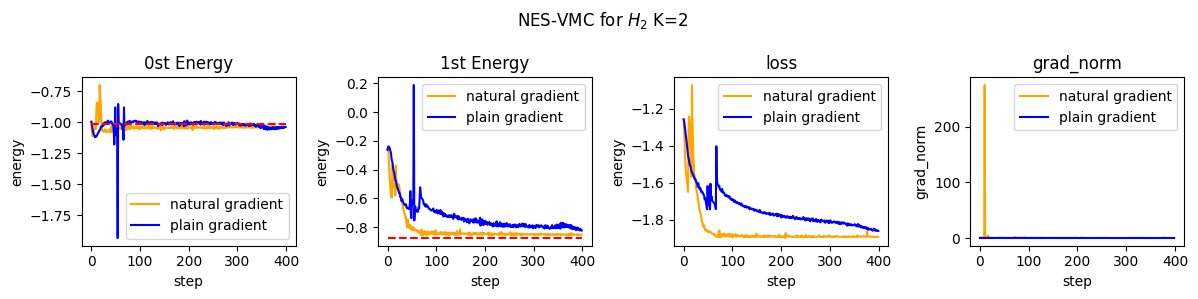

In [48]:
import matplotlib.pyplot as plt

# 创建 2行1列 的子图
fig, (ax1, ax2, ax3,ax4) = plt.subplots(1, 4, figsize=(12, 3))
fig.suptitle('NES-VMC for $H_2$ K=2 ')
# 第一个子图
ax1.plot(history_natural['energy_0st'],color='orange',label='natural gradient')
ax1.plot(history_plain['energy_0st'],color='blue',label='plain gradient')
ax1.hlines(E_fcis[0],0,len(history['energy_0st']),linestyle='--',color='red')
ax1.set_title('0st Energy')
ax1.set_ylabel('energy')
ax1.set_xlabel('step')
ax1.legend()

ax2.plot(history_natural['energy_1st'],color='orange',label='natural gradient')
ax2.plot(history_plain['energy_1st'],color='blue',label='plain gradient')
ax2.hlines(E_fcis[1],0,len(history['energy_1st']),linestyle='--',color='red')
ax2.set_title('1st Energy')
ax2.set_ylabel('energy')
ax2.set_xlabel('step')      
ax2.legend()

# 第二个子图
ax3.plot(history_natural['loss'],color='orange',label='natural gradient')        
ax3.plot(history_plain['loss'],color='blue',label='plain gradient')
ax3.set_title('loss')
ax3.set_xlabel('step')
ax3.set_ylabel('energy')
ax3.legend()

# 第三个子图
ax4.plot(history_natural['grad_norm'],color='orange',label='natural gradient')
ax4.plot(history_plain['grad_norm'],color='blue',label='plain gradient')
ax4.set_title('grad_norm')
ax4.set_xlabel('step')
ax4.set_ylabel('grad_norm')
ax4.legend()

plt.tight_layout()  # 自动调整间距
plt.show()

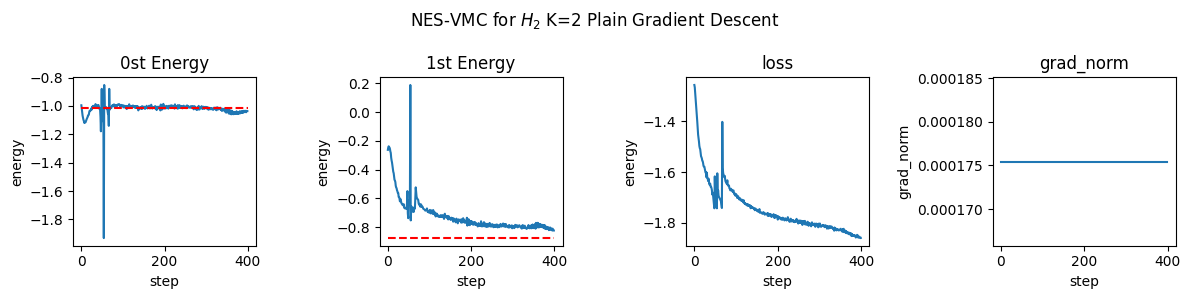

In [39]:
import matplotlib.pyplot as plt

# 创建 2行1列 的子图
fig, (ax1, ax2, ax3,ax4) = plt.subplots(1, 4, figsize=(12, 3))
fig.suptitle('NES-VMC for $H_2$ K=2 Plain Gradient Descent')
# 第一个子图
ax1.plot(history['energy_0st'])
ax1.hlines(E_fcis[0],0,len(history['energy_0st']),linestyle='--',color='red')
ax1.set_title('0st Energy')
ax1.set_ylabel('energy')
ax1.set_xlabel('step')

ax2.plot(history['energy_1st'])
ax2.hlines(E_fcis[1],0,len(history['energy_1st']),linestyle='--',color='red')
ax2.set_title('1st Energy')
ax2.set_ylabel('energy')
ax2.set_xlabel('step')

# 第二个子图
ax3.plot(history['loss'])
ax3.set_title('loss')
ax3.set_xlabel('step')
ax3.set_ylabel('energy')

# 第三个子图
ax4.plot(history['grad_norm'])
ax4.set_title('grad_norm')
ax4.set_xlabel('step')
ax4.set_ylabel('grad_norm')

plt.tight_layout()  # 自动调整间距
plt.show()

剖析为啥有毛病 

In [ ]:
history['energy_0st'][40:45]

In [23]:
from collections import Counter
import numpy as np
def sampler_info(samples:jnp.array,K:int):
    test_samples = np.array(samples.reshape(-1, 4*K))
    count = Counter(tuple(each_row.tolist()) for each_row in test_samples)
    for tpl, count_ in count.items():
        print(f"元组 {tpl} 出现了 {count_} 次")
    return count


sampler_info(history['samples'][100],K)

元组 (1, 0, 1, 0, 1, 0, 0, 1) 出现了 743 次
元组 (0, 1, 1, 0, 1, 0, 1, 0) 出现了 519 次
元组 (1, 0, 1, 0, 0, 1, 1, 0) 出现了 528 次
元组 (1, 0, 0, 1, 1, 0, 1, 0) 出现了 811 次
元组 (0, 1, 0, 1, 1, 0, 1, 0) 出现了 164 次
元组 (0, 1, 1, 0, 1, 0, 0, 1) 出现了 125 次
元组 (1, 0, 1, 0, 0, 1, 0, 1) 出现了 169 次
元组 (1, 0, 0, 1, 0, 1, 1, 0) 出现了 108 次
元组 (0, 1, 0, 1, 1, 0, 0, 1) 出现了 9 次
元组 (1, 0, 0, 1, 0, 1, 0, 1) 出现了 15 次
元组 (0, 1, 1, 0, 0, 1, 0, 1) 出现了 8 次
元组 (0, 1, 0, 1, 0, 1, 1, 0) 出现了 1 次


Counter({(1, 0, 0, 1, 1, 0, 1, 0): 811,
         (1, 0, 1, 0, 1, 0, 0, 1): 743,
         (1, 0, 1, 0, 0, 1, 1, 0): 528,
         (0, 1, 1, 0, 1, 0, 1, 0): 519,
         (1, 0, 1, 0, 0, 1, 0, 1): 169,
         (0, 1, 0, 1, 1, 0, 1, 0): 164,
         (0, 1, 1, 0, 1, 0, 0, 1): 125,
         (1, 0, 0, 1, 0, 1, 1, 0): 108,
         (1, 0, 0, 1, 0, 1, 0, 1): 15,
         (0, 1, 0, 1, 1, 0, 0, 1): 9,
         (0, 1, 1, 0, 0, 1, 0, 1): 8,
         (0, 1, 0, 1, 0, 1, 1, 0): 1})

In [ ]:
sampler_info(history['samples'][102],K)

In [ ]:

print(f'我当时保存的: loss: {history["loss"][102]:.3f}|energy_0st: {history["energy_0st"][102]:.3f}|grad_norm: {history["grad_norm"][102]:.3f}')
test_samples = history['samples'][102]
test_params = history['params'][101]
# 3. 计算能量和自然梯度（逻辑和原代码一致）
grad, loss_mean, E_L_mean = nes_vmc_gradient(ha=ha,
                                                total_matrix_machine=total_matrix_machine,
                                                total_machine=total_machine,
                                                single_machine_list=single_machine_list,
                                                total_params=test_params,
                                                x_batch=test_samples.reshape(-1,K,4))

grad_flat , grad_unravel_fn = ravel_pytree(grad)
grad_norm = jnp.linalg.norm(grad_flat)

eig_vals, eig_vecs = jnp.linalg.eigh(E_L_mean)
print(f'我基于当时的 Samples 尝试复现:')
print(f"grad_norm: {grad_norm:.3f}|loss_mean: {loss_mean:.3f}|energy_0st: {eig_vals[0]:.3f}")
print(E_L_mean)

In [ ]:
from NES_VMC import NES_loss_energy

trace, E_L = NES_loss_energy(ha=ha,
                total_matrix_machine=total_matrix_machine,
                single_machine_list=single_machine_list,
                total_params=total_params,
                x=test_samples.reshape(-1,2,4))

trace

In [ ]:
test_samples.reshape(-1,2,4)[0]

In [ ]:
E_L[0]

In [ ]:
def NES_loss_energy(ha, total_matrix_machine,single_machine_list,total_params, x):
    log_M = total_matrix_machine(total_params,x)
    Psi_Matrix = jnp.exp(log_M)
    # 添加正则化项，防止矩阵奇异
    #Psi_Matrix += 1e-6 * jnp.eye(Psi_Matrix.shape[0])
    H_psi_x = Ham_Psi(ha,single_machine_list,total_params,x)
    Psi_Matrix_inv = jnp.linalg.solve(Psi_Matrix, H_psi_x)
    return jnp.real(jnp.trace(Psi_Matrix_inv, axis1=-2, axis2=-1)), Psi_Matrix_inv

In [ ]:
total_matrix_machine(total_params, history['samples'][41].reshape(-1,K,4))